# Smoke analysis — local smoke_test log

Parses plain-text stdout from `scripts/smoke_test.sh` (written to `scripts/smoke.txt`).

Layout-aware via `scripts/smoke_analysis/layout.py` (follows `main.py`: **milos** farmer-only, or `agent.zoning.CURRENT` for FIVE / TWO / THREE).

Covers hire-on-demand acceptance checks: write-on-solve, skip-not-break cascade, dawn empties (stacked land1+land2), planner zone solves (`[planner] wsp zone=…`), probe/BUY_LAND, and land2 `keep` stranding.

**Kaggle-faithful:** smokes are unseeded (env picks the seed). Compare code versions with multiple runs, not a pinned seed:

```bash
bash scripts/smoke_test.sh              # single run -> scripts/smoke.txt
SMOKE_RUNS=8 bash scripts/smoke_multi_run.sh   # distribution -> scripts/smoke_runs/
```

In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))

from smoke_analysis import (
    analyze,
    plot_earnings_by_day,
    plot_earnings_by_zone,
    plot_sell_price_heatmap,
    plot_smoke,
    plot_stuck_skip_freq,
    plot_us_vs_opp_daily,
    plot_us_vs_opp_money_hours,
    plot_worker_actions,
    plot_zone_capacity,
    plot_zone_earnings_vs_cost,
    summarize,
    summarize_distribution,
)

SMOKE_LOG = ROOT / "scripts/smoke.txt"
print(SMOKE_LOG, SMOKE_LOG.exists())

/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke.txt True


In [31]:
report = analyze(SMOKE_LOG)
print(summarize(report))

log=smoke seed=None layout=milos_threeland12 package=milos land2=4 workers reward=None smoke_passed=True buy_land_day=7
PASS total=1063 HIRE total=258
replan_days=21 skip_cascade=0 infeasible=0
vs_opp: tile_ops us=2712 opp=3487 reward_us=101697.0 reward_opp=177447.0 margin=-75750.0
idle: mean_empty=1.0 land2_mean=0.9 hire5_empty_days=10 max_streak=10
stuck: workers=['hire5', 'hire6'] healed<=5d=- permanent/slow=['hire5', 'hire6']
  [OK] write_day0_ge1: all day0≥1 writes present
  [OK] skip_not_break: 0 post-buy skips, cascade continued
  [OK] no_dark_land2_keep: no long land2 keep streaks
  [OK] thin_writes_logged: no thin zones
  [OK] hire5_idle_proxy: hire4_empty dawn days=11, hire4 empty=1 INFEASIBLE=0
  [OK] missing_from_solved: no worker missing solved ≥3 replans
  [OK] stale_start_blocks: 0 start_block age≥2
  [OK] smoke_health: parsed from log
fc_err premium d3+ mean=17.26
fc_err WOOL d3+ range=66.0
shed: days_at_cap=1 max_cap_streak=1
disposal: room=2 animal_cap=4 sell_lead=0
t

/media/wlaki/W/DS_projects/Kaggle/kaggriculture/scripts/smoke_analysis/plot.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


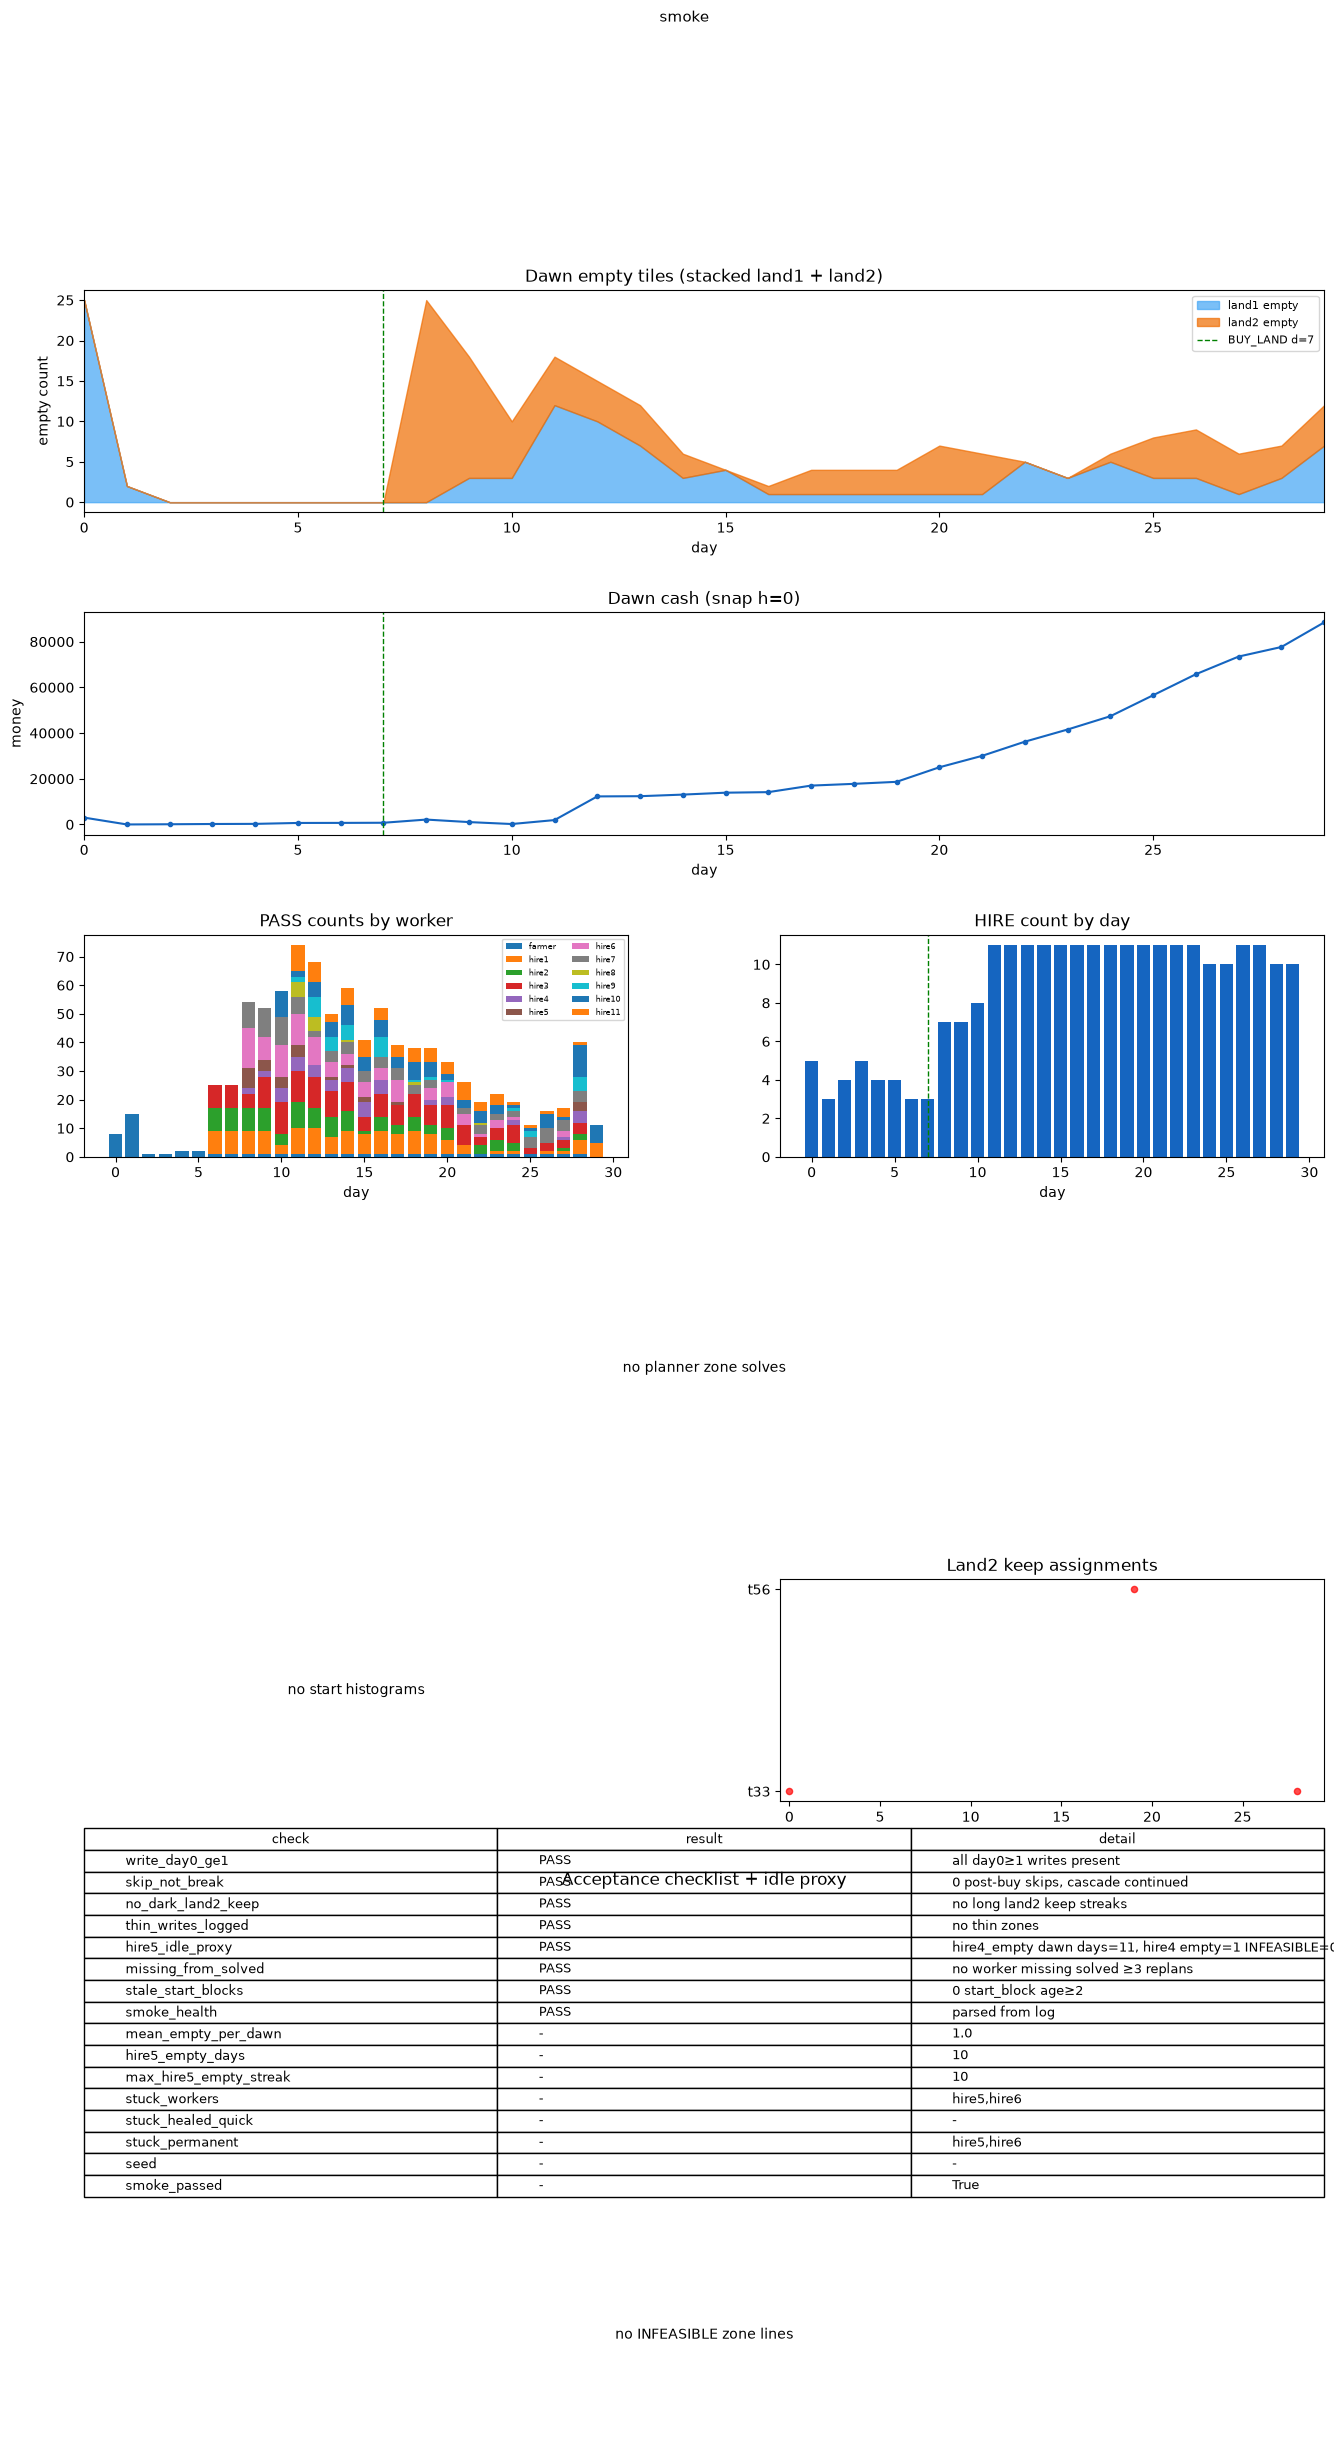

In [32]:
plot_smoke(report)

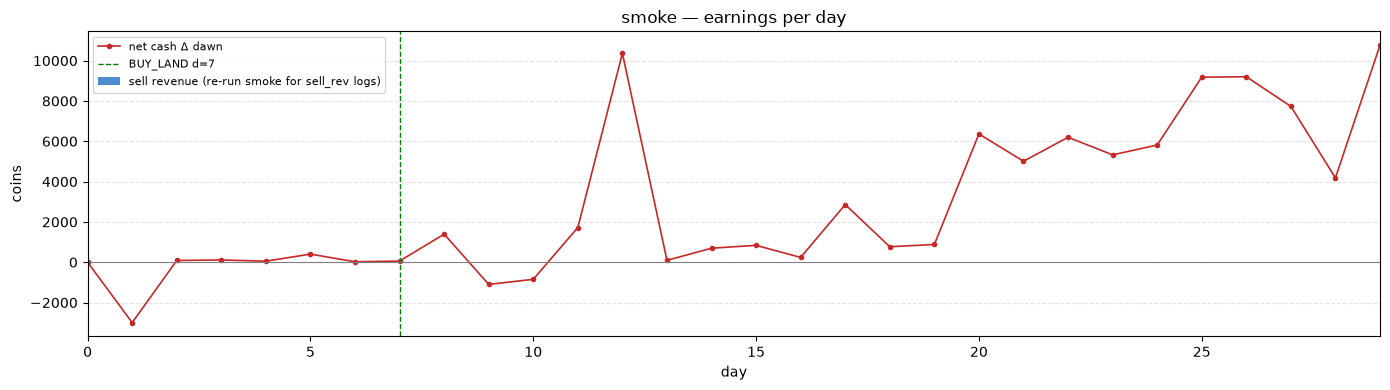

In [33]:
plot_earnings_by_day(report)

## Us vs opp (ops, cash, workers, efficiency)

Requires smoke against `scripts/v55_logged_opponent.py` (`[opp]` / `[opp_snap]` lines). Seven daily panels: total tile ops; **tiles operated** (us: max(qtiles, `[snap] live=`); opp: `[opp_snap] live=`); net cash Δ; **workers** (us: max of qtiles zones, distinct `[exec]` farmer+handN/day, `[snap] hands+1`; opp: `[exec]` actors); ops/tile; avg tiles/worker; avg ops/worker.

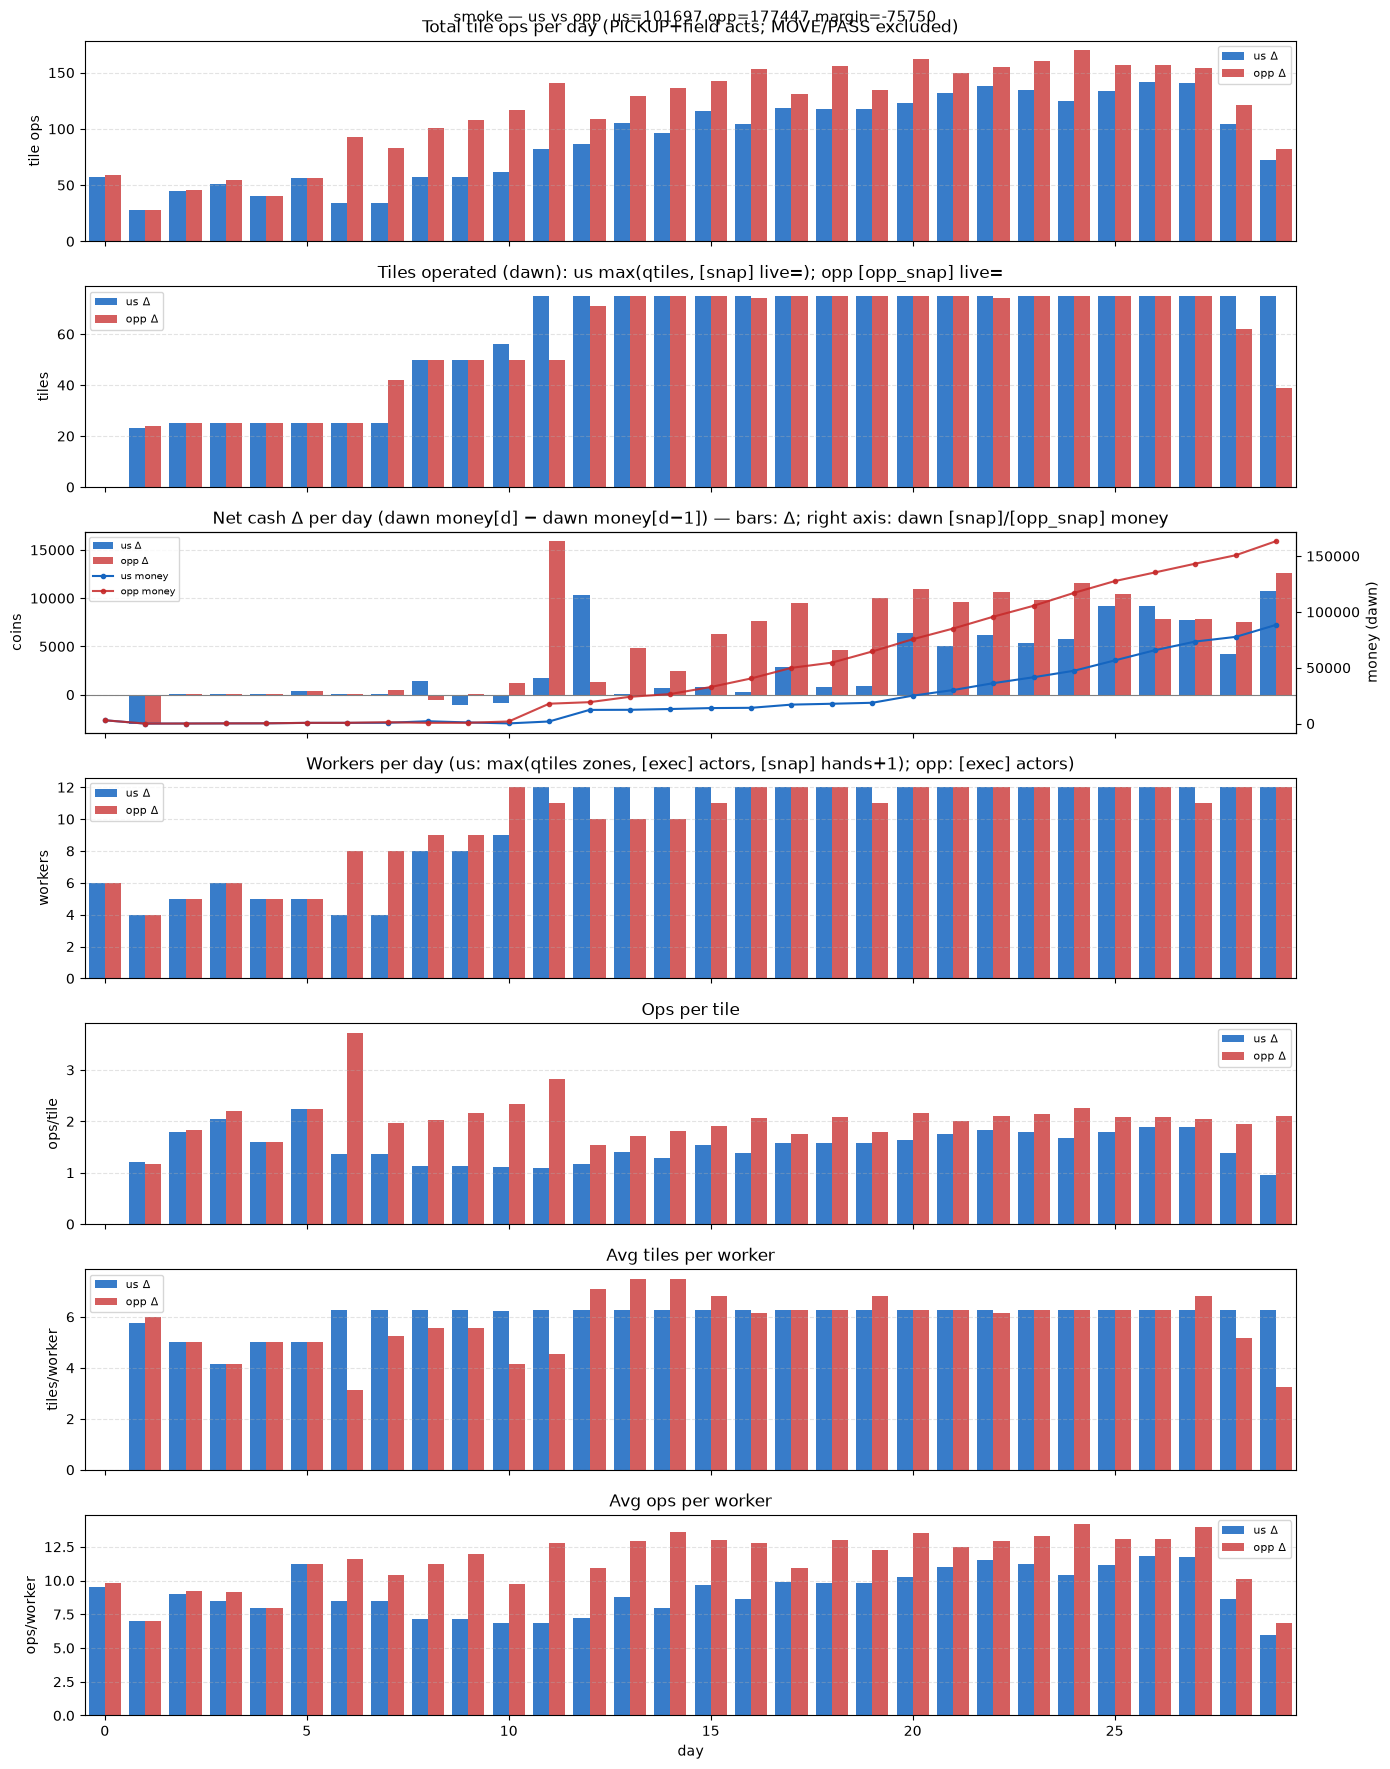

In [34]:
plot_us_vs_opp_daily(report)

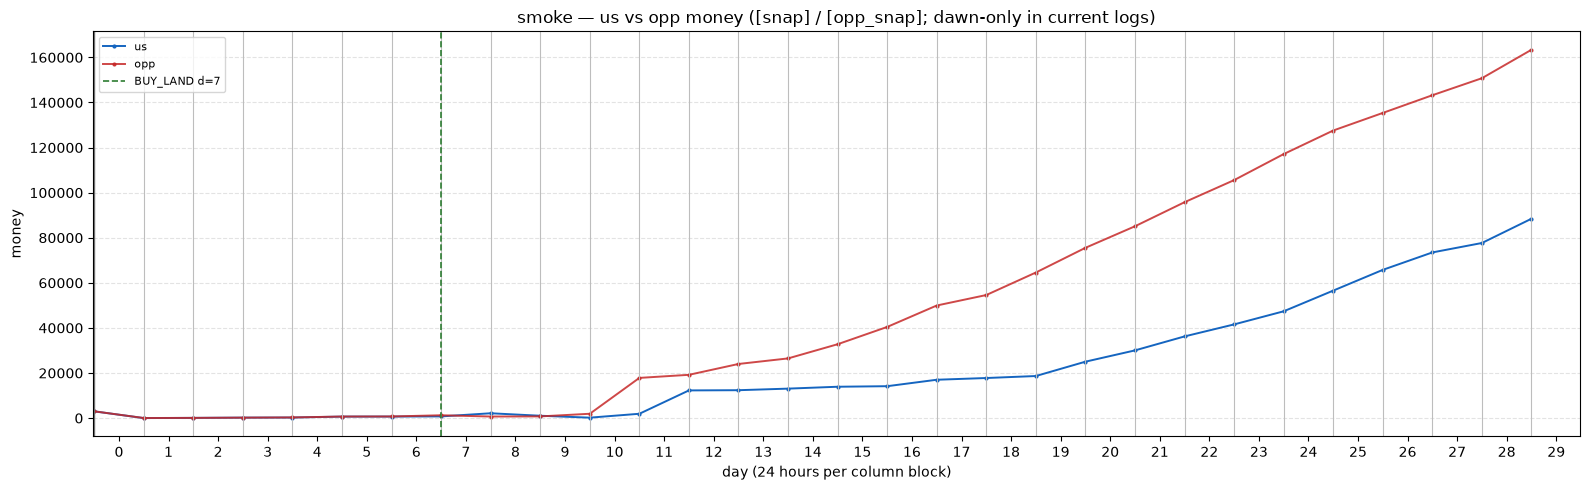

In [35]:
plot_us_vs_opp_money_hours(report)


## Sells by relative price

Heatmap: **y** = product, **x** = dawn quote / base, **color** = units sold. Uses `[snap]` dawn prices + `[exec]`/`[opp]` `SELL` lines (same-day sells share the dawn quote). White dash = 1.0× base.

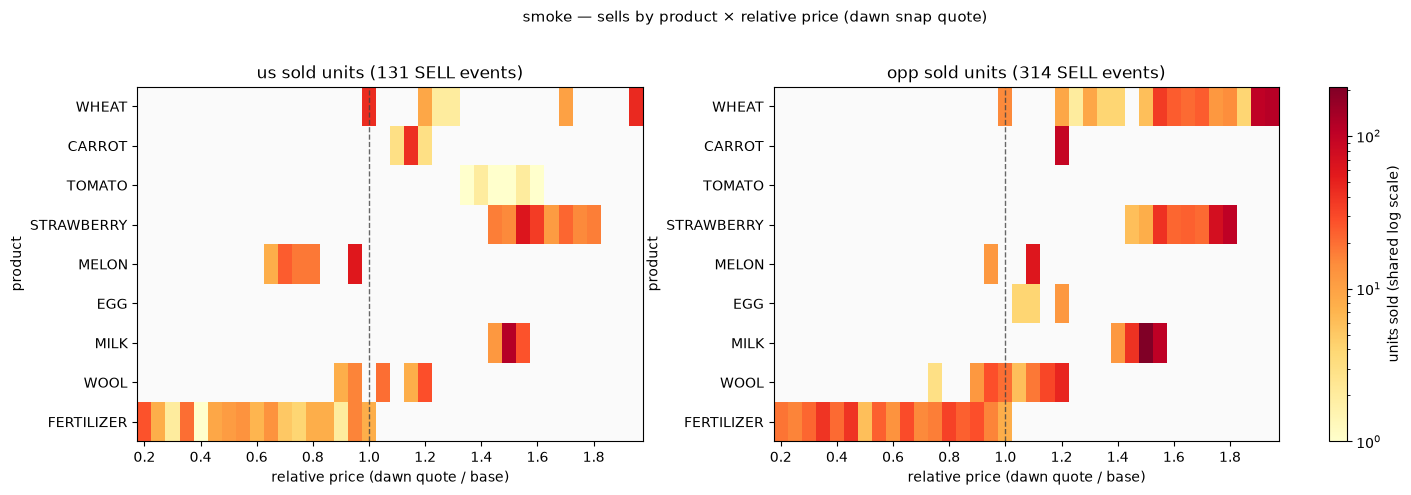

In [36]:
plot_sell_price_heatmap(report)

In [37]:
# plot_fc_err(report)

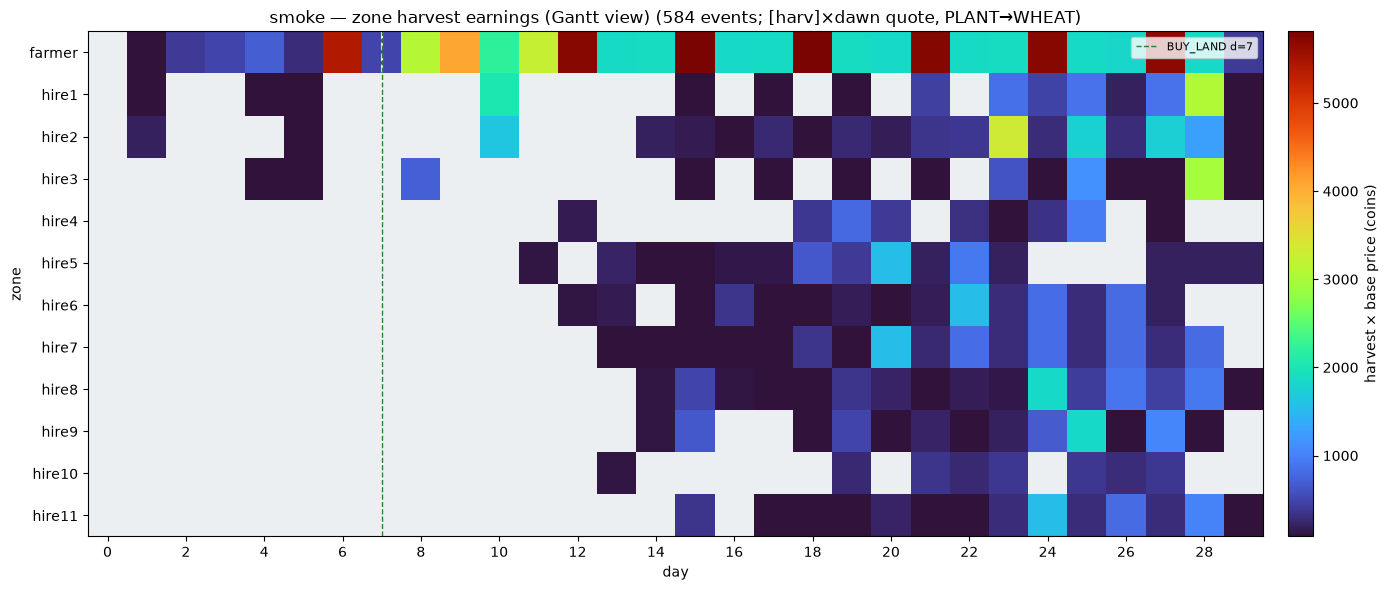

In [38]:
plot_earnings_by_zone(report)

## Zone earnings vs hire cost

One subplot per **zone** (worker): green = daily harvest × dawn crop quote (same proxy as the Gantt above); red = negative `HAND_DAILY_COST` from the live layout while the zone is active (first `[exec] hand*=` / `[hands] h0` day). Blue line = net proxy. Compare SW hires (e.g. hire11–14) to their fib daily burn.

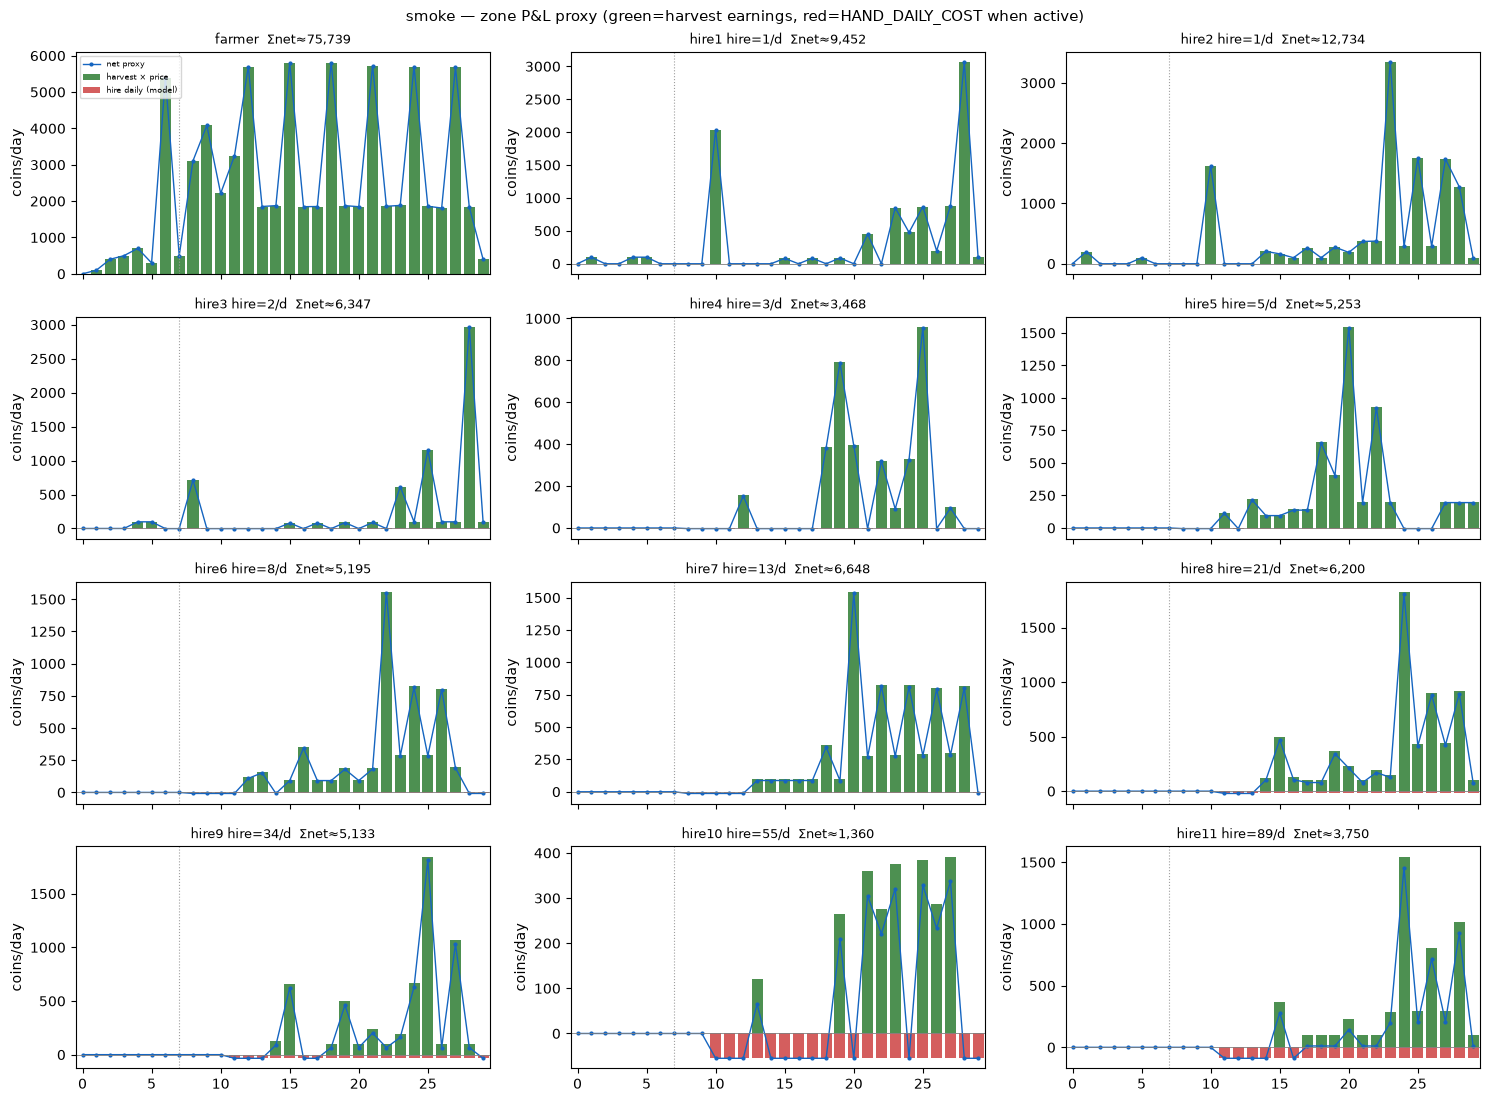

In [39]:
plot_zone_earnings_vs_cost(report)

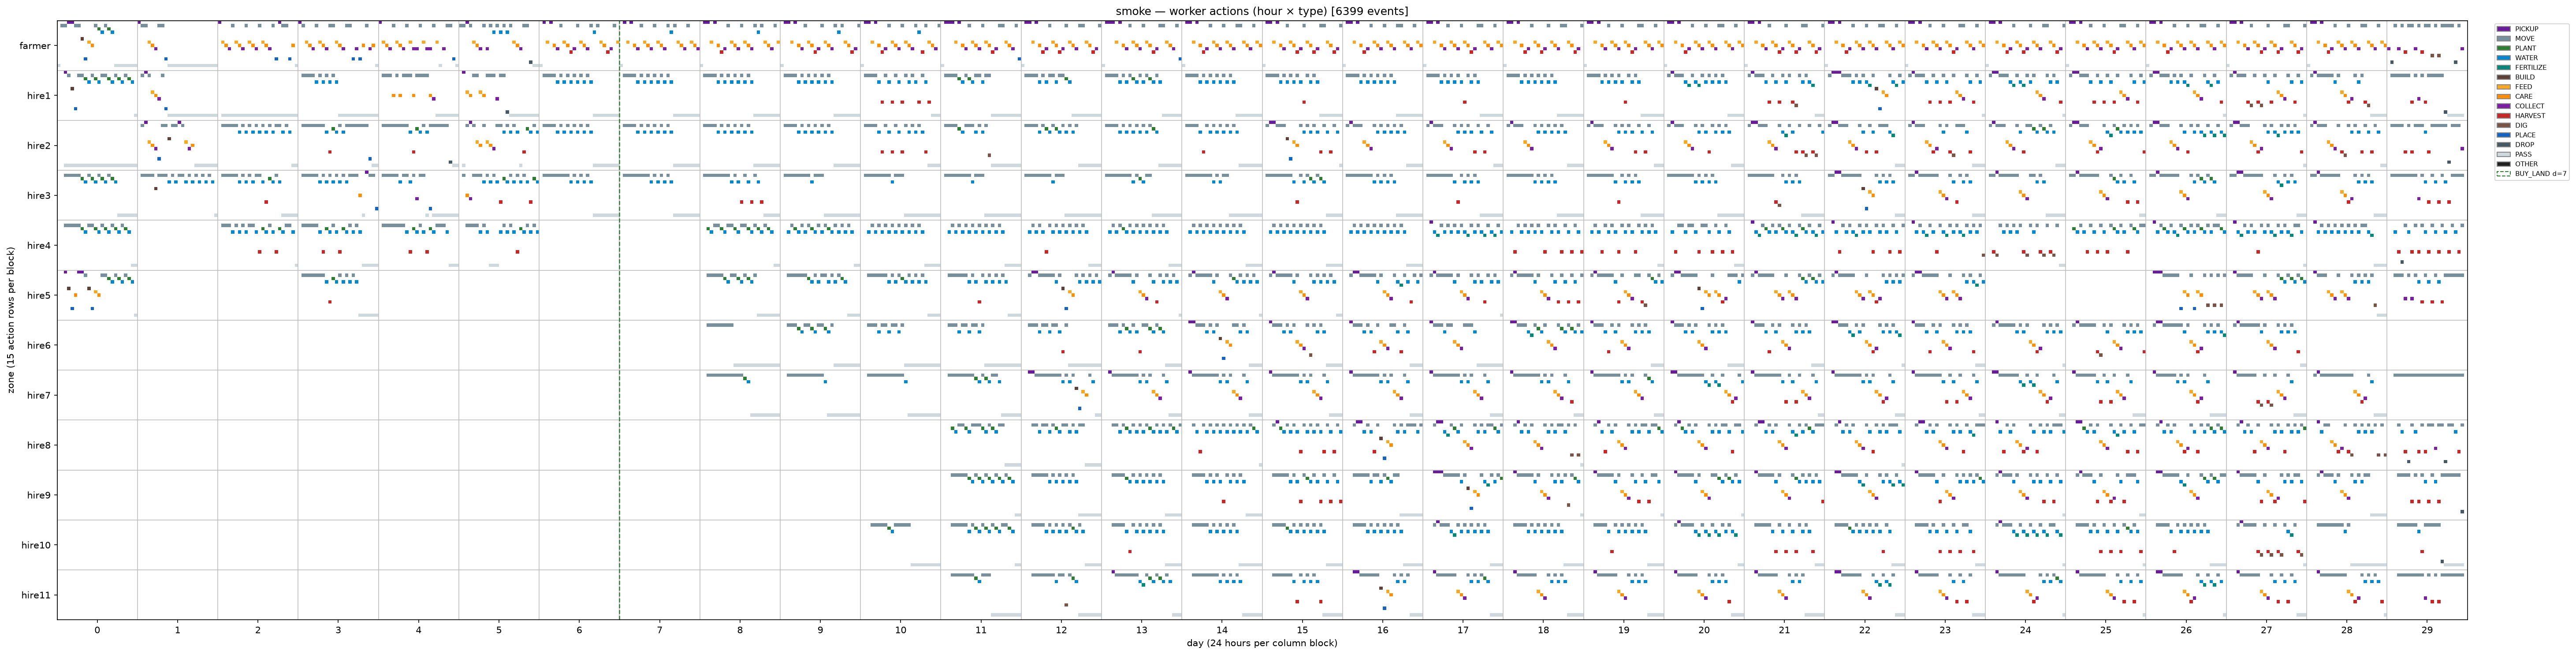

In [40]:
plot_worker_actions(report)

## Zone capacity (est_ops vs executed)

Stacked bars: tile ops + MOVE + PASS (+ reactive feed). Red dots = dawn dry-run `est_ops` (theo tile_ops); green dash = `net_tile_ops`.

After the plot: **per-day, per-tile** theo vs act action lists (mismatch tiles only).

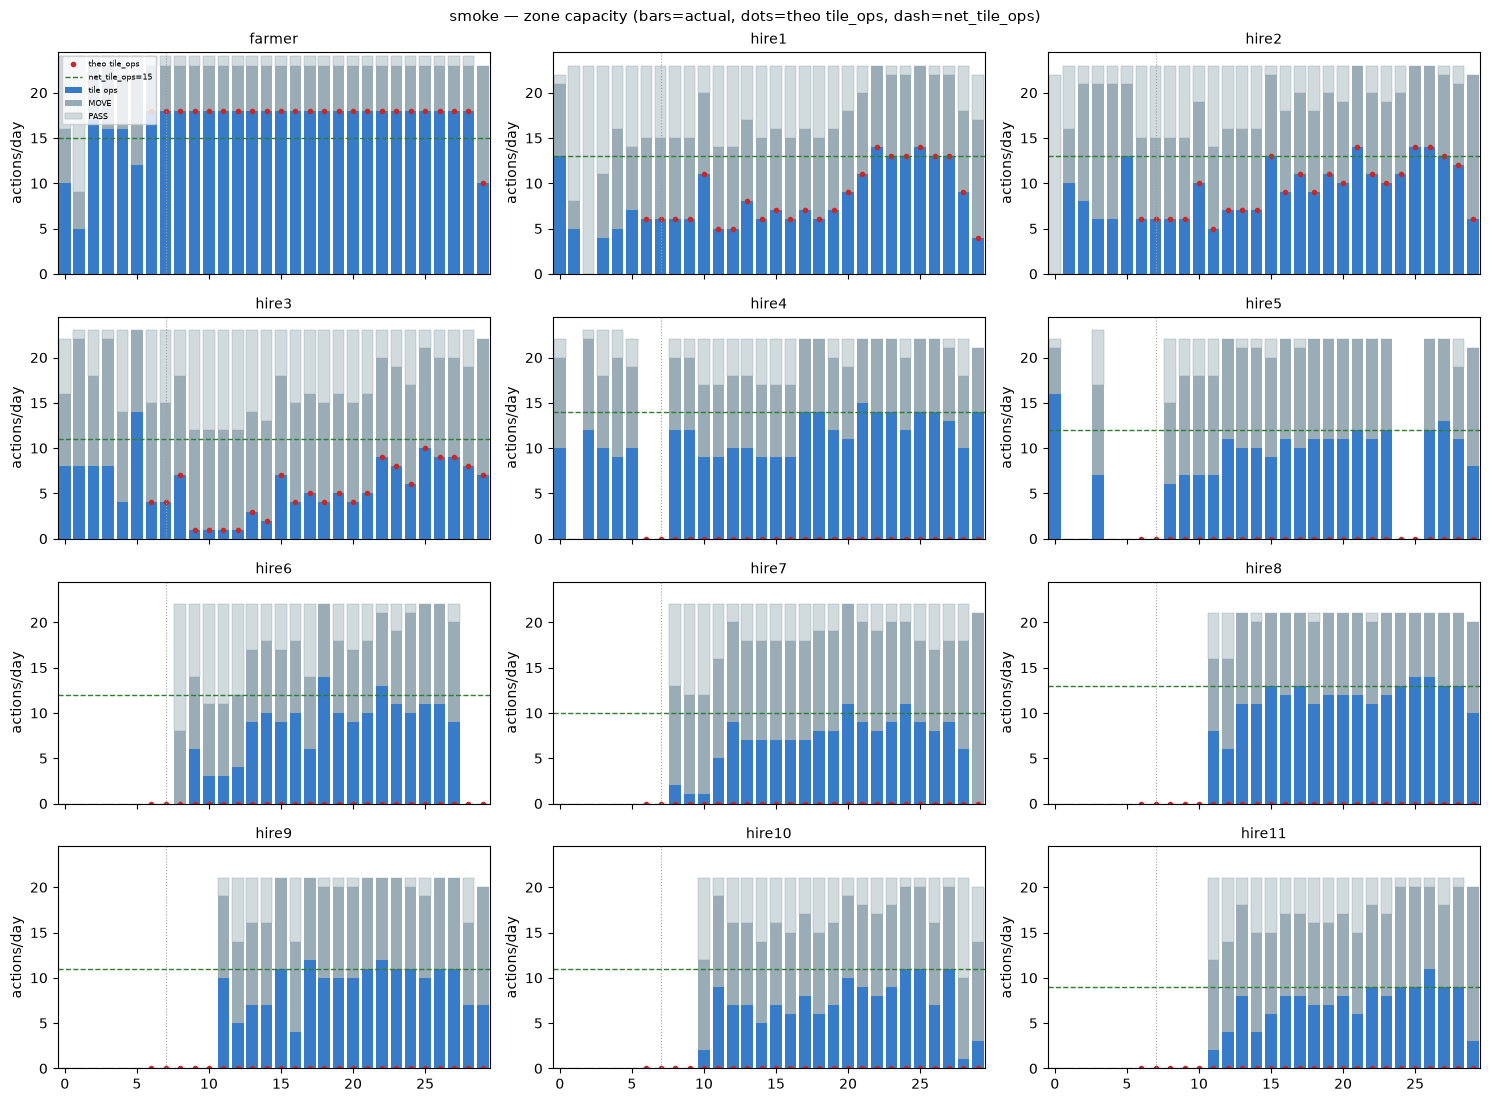

farmer: theo vs act (mismatch days only; matches chart tile_ops totals)
  d=0
    shed theo: -
    shed act:  PICKUP PICKUP BUILD_PASTURE PLACE FEED CARE PLANT WATER PLANT WATER
  d=1
    shed theo: -
    shed act:  PICKUP FEED CARE COLLECT_FERTILIZER PLACE
  d=2
    shed theo: -
    shed act:  PICKUP FEED CARE COLLECT_FERTILIZER FEED CARE COLLECT_FERTILIZER FEED CARE COLLECT_FERTILIZER FEED CARE COLLECT_FERTILIZER PLACE PICKUP PLACE CARE
  d=3
    shed theo: -
    shed act:  PICKUP FEED CARE COLLECT_FERTILIZER FEED CARE COLLECT_FERTILIZER FEED CARE COLLECT_FERTILIZER PLACE COLLECT_FERTILIZER PLACE CARE COLLECT_FERTILIZER CARE
  d=4
    shed theo: -
    shed act:  PICKUP FEED CARE COLLECT_FERTILIZER FEED CARE COLLECT_FERTILIZER FEED COLLECT_FERTILIZER COLLECT_FERTILIZER FEED COLLECT_FERTILIZER COLLECT_FERTILIZER FEED COLLECT_FERTILIZER PLACE
  d=5
    shed theo: -
    shed act:  PICKUP FEED CARE COLLECT_FERTILIZER COLLECT_FERTILIZER WATER WATER WATER FEED CARE COLLECT_FERTILIZER DROP
h

In [41]:
plot_zone_capacity(report)

## Multi-run: stuck fires vs cascade skips

Diagnose ratchet vs skip-not-break from local stderr (not Kaggle replays).

```bash
SMOKE_RUNS=5 bash scripts/smoke_multi_run.sh   # -> scripts/smoke_runs/run_*.txt
```

- **Stuck fires rare** → ratchet unlikely the regressor; look at skip-not-break staffing thin/failing zones.
- **Skip frequency high** → N=3 ratchet may be too aggressive vs self-heal.

runs=5
reward: min=101007 max=129679 mean=110411 spread=28672 values=[102170, 118049, 101007, 129679, 101148]
stuck_fires: runs_with=3/5 mean=0.6 values=[0, 0, 1, 1, 1]
skip_cascade: mean=15.6 values=[10, 12, 16, 21, 19]
stuck_runs=3/5 stuck_worker_counts=[0, 0, 1, 1, 1]
shed max_cap_streak: mean=0.0 values=[0, 0, 0, 0, 0]
[room] events mean=0.0 values=[0, 0, 0, 0, 0]


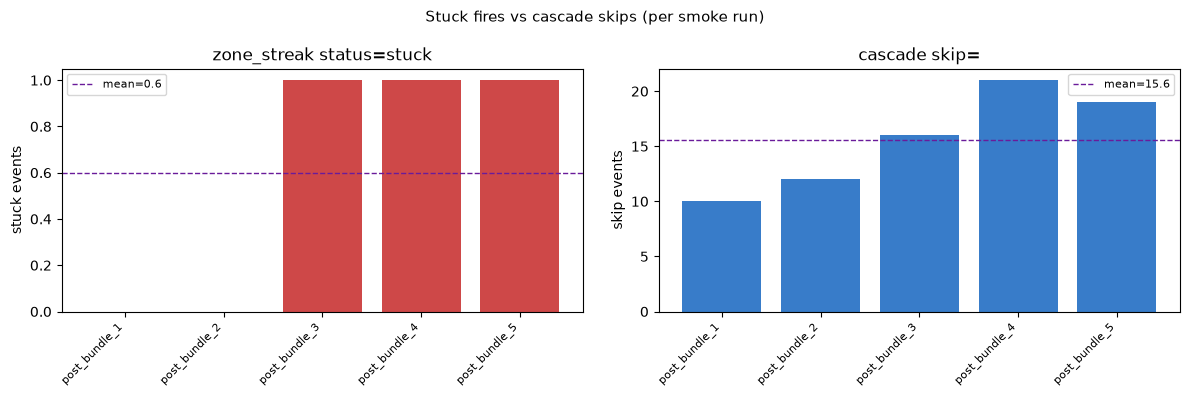

In [42]:
RUNS_DIR = ROOT / "scripts" / "smoke_runs"
run_logs = sorted(RUNS_DIR.glob("post_bundle_*.txt"))
if not run_logs:
    print(f"No logs in {RUNS_DIR} — run: SMOKE_RUNS=5 bash scripts/smoke_multi_run.sh")
else:
    reports = [analyze(p) for p in run_logs]
    print(summarize_distribution(reports))
    plot_stuck_skip_freq(reports)